In [1]:
import pandas as pd 
from pathlib import Path

from power_shapes.loader import load_rte_data
from power_shapes.functions import persistence_diagram
from power_shapes.utils import plot_persistence_diagram

In [15]:
df = load_rte_data(
    Path("../data/donnees-rte.csv")
)
df.dtypes

/Users/mehdielkansouli/Desktop/projets-perso/PowerShapes/power-shapes/src/power_shapes/loader.py:13: DtypeWarning: Columns (23: Ech. comm. Allemagne-Belgique (MW), 28: Gaz - Cogénération (MW)) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';')


datetime               datetime64[us, UTC]
consumption_mw                     float64
solar_mw                           float64
wind_mw                            float64
net_demand_solar_mw                float64
net_demand_mw                      float64
dtype: object

In [16]:
date = pd.to_datetime('2026-06-30', utc=True).date()
day_ts = df[df.datetime.dt.date >= date]
net_load_ts = day_ts.net_demand_solar_mw.values

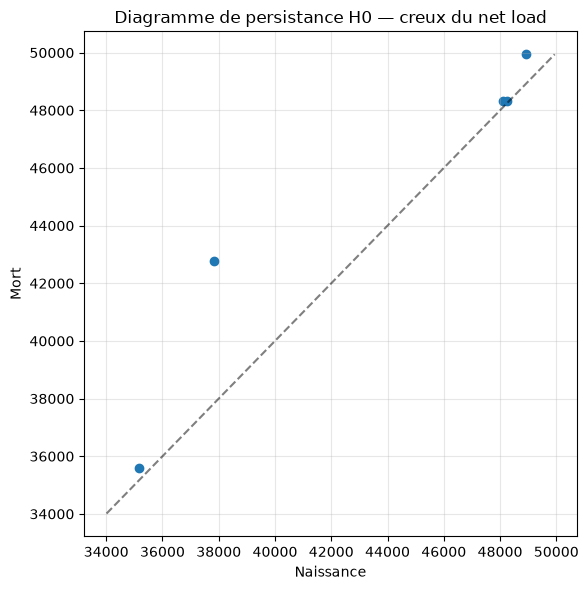

In [18]:
diagram = persistence_diagram(net_load_ts, filtration="sublevel")
plot_persistence_diagram(diagram, net_load_ts)